In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd

# Finds the first location that exists.
DATA_DIRECTORY = next(
    (
        path
        for path in [
            Path("../data/geo_us"),
            Path("data/geo_us"),
            Path("upload"),
        ]
        if path.exists()
    ),
    Path("../data/geo_us"),
)

STATUS_FILENAME = "us_geo_catalog_status.csv"
HISTORY_FILENAME = "gp_history_20260801_20260901_3cbd5060be.json"

# F0 model settings: same assumptions as the static notebook.
MU_EARTH_KM3_S2 = 398_600.4418
GEO_RADIUS_KM = 42_164.0
PHASING_REVOLUTIONS = 1

# Candidate equatorial GEO depot grid.
N_CANDIDATE_STATIONS = 36
STATION_LONGITUDES_DEG = np.linspace(
    -180.0, 180.0, N_CANDIDATE_STATIONS, endpoint=False
)

# Time-series study settings.
# Leave as None to start at the latest usable GP epoch in the file.
REFERENCE_EPOCH_UTC = None
TIME_STEP_MINUTES = 30
STUDY_DURATION = pd.Timedelta(hours=24)  # approximately one sidereal day

OUTPUT_DIRECTORY = Path("outputs/xgeo_time_series_f0")
OUTPUT_DIRECTORY.mkdir(parents=True, exist_ok=True)

print(f"Data directory: {DATA_DIRECTORY.resolve()}")
print(f"Output directory: {OUTPUT_DIRECTORY.resolve()}")

Data directory: C:\Users\leo.langou\OneDrive - West Point\Desktop\2027 AY-1\MA498\Space_Logistics\data\geo_us
Output directory: C:\Users\leo.langou\OneDrive - West Point\Desktop\2027 AY-1\MA498\Space_Logistics\outputs\xgeo_time_series_f0


In [2]:
status = pd.read_csv(DATA_DIRECTORY / STATUS_FILENAME)

with (DATA_DIRECTORY / HISTORY_FILENAME).open("r", encoding="utf-8") as handle:
    history = pd.DataFrame(json.load(handle))

status["NORAD_CAT_ID"] = status["NORAD_CAT_ID"].astype(str)
history["NORAD_CAT_ID"] = history["NORAD_CAT_ID"].astype(str)
history["EPOCH"] = pd.to_datetime(history["EPOCH"], utc=True)

required_columns = [
    "EPOCH",
    "MEAN_MOTION",
    "ECCENTRICITY",
    "INCLINATION",
    "RA_OF_ASC_NODE",
    "ARG_OF_PERICENTER",
    "MEAN_ANOMALY",
    "SEMIMAJOR_AXIS",
]

catalog_ids = set(status["NORAD_CAT_ID"])
states = history[history["NORAD_CAT_ID"].isin(catalog_ids)].copy()

for column in required_columns[1:]:
    states[column] = pd.to_numeric(states[column], errors="coerce")

states = states.dropna(subset=required_columns)

# One state per satellite. These states remain fixed; only their propagated
# geometry changes over the time grid.
reference_states = (
    states.sort_values("EPOCH")
    .groupby("NORAD_CAT_ID", as_index=False)
    .tail(1)
    .sort_values("NORAD_CAT_ID")
    .reset_index(drop=True)
)

excluded_targets = status[
    ~status["NORAD_CAT_ID"].isin(reference_states["NORAD_CAT_ID"])
].copy()

reference_epoch = (
    pd.to_datetime(REFERENCE_EPOCH_UTC, utc=True)
    if REFERENCE_EPOCH_UTC is not None
    else reference_states["EPOCH"].max()
)

TIME_GRID = pd.date_range(
    start=reference_epoch,
    end=reference_epoch + STUDY_DURATION,
    freq=f"{TIME_STEP_MINUTES}min",
    inclusive="left",
)

target_metadata = reference_states[
    [
        "NORAD_CAT_ID",
        "OBJECT_NAME",
        "EPOCH",
        "SEMIMAJOR_AXIS",
        "ECCENTRICITY",
        "INCLINATION",
    ]
].copy().rename(columns={"EPOCH": "REFERENCE_STATE_EPOCH"})

state_age_hours = (
    (reference_epoch - reference_states["EPOCH"]).dt.total_seconds() / 3600.0
)

print(f"Usable targets: {len(reference_states)}")
print(f"Excluded targets: {len(excluded_targets)}")
print(f"Reference epoch: {reference_epoch.isoformat()}")
print(f"Snapshots: {len(TIME_GRID)}")
print(
    "Reference-state age at start "
    f"(median / maximum): {state_age_hours.median():.1f} / "
    f"{state_age_hours.max():.1f} hours"
)

Usable targets: 102
Excluded targets: 22
Reference epoch: 2026-09-03T20:48:38.536416+00:00
Snapshots: 48
Reference-state age at start (median / maximum): 5.3 / 164.5 hours


In [3]:
def solve_kepler(mean_anomaly_rad, eccentricity):
    """Solve Kepler's equation for eccentric anomaly."""
    mean_anomaly_rad = np.mod(mean_anomaly_rad, 2.0 * np.pi)
    eccentric_anomaly = mean_anomaly_rad.copy()

    for _ in range(20):
        step = (
            eccentric_anomaly
            - eccentricity * np.sin(eccentric_anomaly)
            - mean_anomaly_rad
        ) / (1.0 - eccentricity * np.cos(eccentric_anomaly))

        eccentric_anomaly -= step

        if np.max(np.abs(step)) < 1e-13:
            break

    return eccentric_anomaly


def gmst_rad(timestamp):
    """Greenwich mean sidereal time in radians."""
    julian_date = timestamp.timestamp() / 86_400.0 + 2_440_587.5
    centuries = (julian_date - 2_451_545.0) / 36_525.0

    gmst_deg = (
        280.46061837
        + 360.98564736629 * (julian_date - 2_451_545.0)
        + 0.000387933 * centuries**2
        - centuries**3 / 38_710_000.0
    )

    return np.deg2rad(gmst_deg % 360.0)


def propagate_to_ecef(states, epoch):
    """
    F0 two-body propagation of mean elements to a common ECEF snapshot.

    Returns
    -------
    ndarray, shape (n_targets, 3)
        [x, y, z] in km.
    """
    dt_seconds = (epoch - states["EPOCH"]).dt.total_seconds().to_numpy()

    mean_motion_rad_s = (
        states["MEAN_MOTION"].to_numpy() * 2.0 * np.pi / 86_400.0
    )
    mean_anomaly = (
        np.deg2rad(states["MEAN_ANOMALY"].to_numpy())
        + mean_motion_rad_s * dt_seconds
    )

    eccentricity = states["ECCENTRICITY"].to_numpy()
    eccentric_anomaly = solve_kepler(mean_anomaly, eccentricity)

    true_anomaly = 2.0 * np.arctan2(
        np.sqrt(1.0 + eccentricity) * np.sin(eccentric_anomaly / 2.0),
        np.sqrt(1.0 - eccentricity) * np.cos(eccentric_anomaly / 2.0),
    )

    semimajor_axis = states["SEMIMAJOR_AXIS"].to_numpy()
    radius = semimajor_axis * (
        1.0 - eccentricity * np.cos(eccentric_anomaly)
    )

    argument_of_latitude = (
        np.deg2rad(states["ARG_OF_PERICENTER"].to_numpy()) + true_anomaly
    )
    inclination = np.deg2rad(states["INCLINATION"].to_numpy())
    raan = np.deg2rad(states["RA_OF_ASC_NODE"].to_numpy())

    x_eci = radius * (
        np.cos(raan) * np.cos(argument_of_latitude)
        - np.sin(raan) * np.sin(argument_of_latitude) * np.cos(inclination)
    )
    y_eci = radius * (
        np.sin(raan) * np.cos(argument_of_latitude)
        + np.cos(raan) * np.sin(argument_of_latitude) * np.cos(inclination)
    )
    z_eci = radius * np.sin(argument_of_latitude) * np.sin(inclination)

    theta = gmst_rad(epoch)

    x_ecef = np.cos(theta) * x_eci + np.sin(theta) * y_eci
    y_ecef = -np.sin(theta) * x_eci + np.cos(theta) * y_eci

    return np.column_stack([x_ecef, y_ecef, z_eci])

In [4]:
station_longitudes_rad = np.deg2rad(STATION_LONGITUDES_DEG)

stations = pd.DataFrame(
    {
        "STATION_ID": [
            f"FS_{index:02d}"
            for index in range(1, N_CANDIDATE_STATIONS + 1)
        ],
        "LONGITUDE_DEG": STATION_LONGITUDES_DEG,
    }
)

stations["X_ECEF_KM"] = GEO_RADIUS_KM * np.cos(station_longitudes_rad)
stations["Y_ECEF_KM"] = GEO_RADIUS_KM * np.sin(station_longitudes_rad)
stations["Z_ECEF_KM"] = 0.0


def wrap_to_pi(angle_rad):
    return (np.asarray(angle_rad) + np.pi) % (2.0 * np.pi) - np.pi


def phasing_one_way_dv_km_s(
    angular_separation_rad,
    revolutions=PHASING_REVOLUTIONS,
):
    """Minimum two-impulse inner/outer GEO phasing cost."""
    separation = np.abs(wrap_to_pi(angular_separation_rad))

    geo_period_s = (
        2.0 * np.pi * np.sqrt(GEO_RADIUS_KM**3 / MU_EARTH_KM3_S2)
    )
    geo_speed = np.sqrt(MU_EARTH_KM3_S2 / GEO_RADIUS_KM)

    period_inner = geo_period_s * (
        1.0 - separation / (2.0 * np.pi * revolutions)
    )
    period_outer = geo_period_s * (
        1.0 + separation / (2.0 * np.pi * revolutions)
    )

    def transfer_dv(period):
        phasing_semimajor_axis = (
            MU_EARTH_KM3_S2 * (period / (2.0 * np.pi)) ** 2
        ) ** (1.0 / 3.0)

        speed_at_geo = np.sqrt(
            MU_EARTH_KM3_S2
            * (2.0 / GEO_RADIUS_KM - 1.0 / phasing_semimajor_axis)
        )

        return 2.0 * np.abs(speed_at_geo - geo_speed)

    return np.minimum(transfer_dv(period_inner), transfer_dv(period_outer))


def hohmann_dv_km_s(r1_km, r2_km):
    dv1 = np.sqrt(MU_EARTH_KM3_S2 / r1_km) * (
        np.sqrt(2.0 * r2_km / (r1_km + r2_km)) - 1.0
    )
    dv2 = np.sqrt(MU_EARTH_KM3_S2 / r2_km) * (
        1.0 - np.sqrt(2.0 * r1_km / (r1_km + r2_km))
    )

    return np.abs(dv1) + np.abs(dv2)


def station_target_costs_km_s(
    target_longitude_rad,
    target_inclination_deg,
    target_semimajor_axis_km,
    station_longitudes_deg,
):
    """
    F0 one-way station-to-target screening cost.

    C = phasing Δv + plane-change Δv + radial/Hohmann Δv
    """
    target_longitude_rad = np.asarray(target_longitude_rad)
    target_inclination_deg = np.asarray(target_inclination_deg)
    target_semimajor_axis_km = np.asarray(target_semimajor_axis_km)

    longitude_dv = phasing_one_way_dv_km_s(
        target_longitude_rad[:, None]
        - np.deg2rad(station_longitudes_deg)[None, :]
    )

    geo_speed = np.sqrt(MU_EARTH_KM3_S2 / GEO_RADIUS_KM)
    plane_change_dv = (
        2.0
        * geo_speed
        * np.sin(np.deg2rad(target_inclination_deg)[:, None] / 2.0)
    )

    radial_dv = hohmann_dv_km_s(
        GEO_RADIUS_KM,
        target_semimajor_axis_km[:, None],
    )

    return longitude_dv + plane_change_dv + radial_dv

In [5]:
n_times = len(TIME_GRID)
n_targets = len(reference_states)
n_stations = len(stations)

# Dimensions:
# target_ecef_km[t, i, xyz]
# target_longitude_rad[t, i]
# one_way_cost_km_s[t, i, j]
target_ecef_km = np.empty((n_times, n_targets, 3))
target_longitude_rad = np.empty((n_times, n_targets))
one_way_cost_km_s = np.empty((n_times, n_targets, n_stations))

target_inclination_deg = reference_states["INCLINATION"].to_numpy()
target_semimajor_axis_km = reference_states["SEMIMAJOR_AXIS"].to_numpy()

for time_index, epoch in enumerate(TIME_GRID):
    ecef_snapshot = propagate_to_ecef(reference_states, epoch)

    target_ecef_km[time_index] = ecef_snapshot
    target_longitude_rad[time_index] = np.arctan2(
        ecef_snapshot[:, 1],
        ecef_snapshot[:, 0],
    )

    one_way_cost_km_s[time_index] = station_target_costs_km_s(
        target_longitude_rad[time_index],
        target_inclination_deg,
        target_semimajor_axis_km,
        stations["LONGITUDE_DEG"].to_numpy(),
    )

assert np.isfinite(target_ecef_km).all()
assert np.isfinite(one_way_cost_km_s).all()

print(f"Target-state tensor: {target_ecef_km.shape}")
print(f"One-way cost tensor: {one_way_cost_km_s.shape}")
print("Axis order: (time, target, candidate station)")

Target-state tensor: (48, 102, 3)
One-way cost tensor: (48, 102, 36)
Axis order: (time, target, candidate station)


In [6]:
nearest_candidate_cost_km_s = one_way_cost_km_s.min(axis=2)

time_summary = pd.DataFrame(
    {
        "EPOCH": TIME_GRID,
        "MEAN_NEAREST_CANDIDATE_DV_M_S": (
            nearest_candidate_cost_km_s.mean(axis=1) * 1000.0
        ),
        "MEDIAN_NEAREST_CANDIDATE_DV_M_S": (
            np.median(nearest_candidate_cost_km_s, axis=1) * 1000.0
        ),
        "WORST_NEAREST_CANDIDATE_DV_M_S": (
            nearest_candidate_cost_km_s.max(axis=1) * 1000.0
        ),
    }
)

np.savez_compressed(
    OUTPUT_DIRECTORY / "f0_time_series_cost_tensor.npz",
    epoch_ns_utc=TIME_GRID.asi8,
    target_norad_ids=target_metadata["NORAD_CAT_ID"].to_numpy(),
    station_ids=stations["STATION_ID"].to_numpy(),
    target_ecef_km=target_ecef_km,
    target_longitude_rad=target_longitude_rad,
    one_way_cost_km_s=one_way_cost_km_s,
)

target_metadata.to_csv(
    OUTPUT_DIRECTORY / "target_metadata.csv",
    index=False,
)
stations.to_csv(
    OUTPUT_DIRECTORY / "candidate_stations.csv",
    index=False,
)
time_summary.to_csv(
    OUTPUT_DIRECTORY / "candidate_cost_time_summary.csv",
    index=False,
)

run_metadata = {
    "model": "F0: two-body propagation; phasing + plane-change + radial/Hohmann cost",
    "reference_epoch_utc": reference_epoch.isoformat(),
    "time_step_minutes": int(TIME_STEP_MINUTES),
    "study_duration_hours": STUDY_DURATION.total_seconds() / 3600.0,
    "n_times": int(n_times),
    "n_targets": int(n_targets),
    "n_candidate_stations": int(n_stations),
}

with (OUTPUT_DIRECTORY / "run_metadata.json").open("w", encoding="utf-8") as handle:
    json.dump(run_metadata, handle, indent=2)

print("Saved time-series data to:", OUTPUT_DIRECTORY)
time_summary.head()

Saved time-series data to: outputs\xgeo_time_series_f0


,EPOCH,MEAN_NEAREST_CANDIDATE_DV_M_S,MEDIAN_NEAREST_CANDIDATE_DV_M_S,WORST_NEAREST_CANDIDATE_DV_M_S
0,2026-09-03 20:48:38.536416+00:00,215.814754,64.589287,1850.733353
1,2026-09-03 21:18:38.536416+00:00,215.904676,64.608664,1856.639977
2,2026-09-03 21:48:38.536416+00:00,215.974392,64.625924,1860.397037
3,2026-09-03 22:18:38.536416+00:00,216.023563,64.640565,1861.892585
4,2026-09-03 22:48:38.536416+00:00,216.058528,64.652234,1861.197555


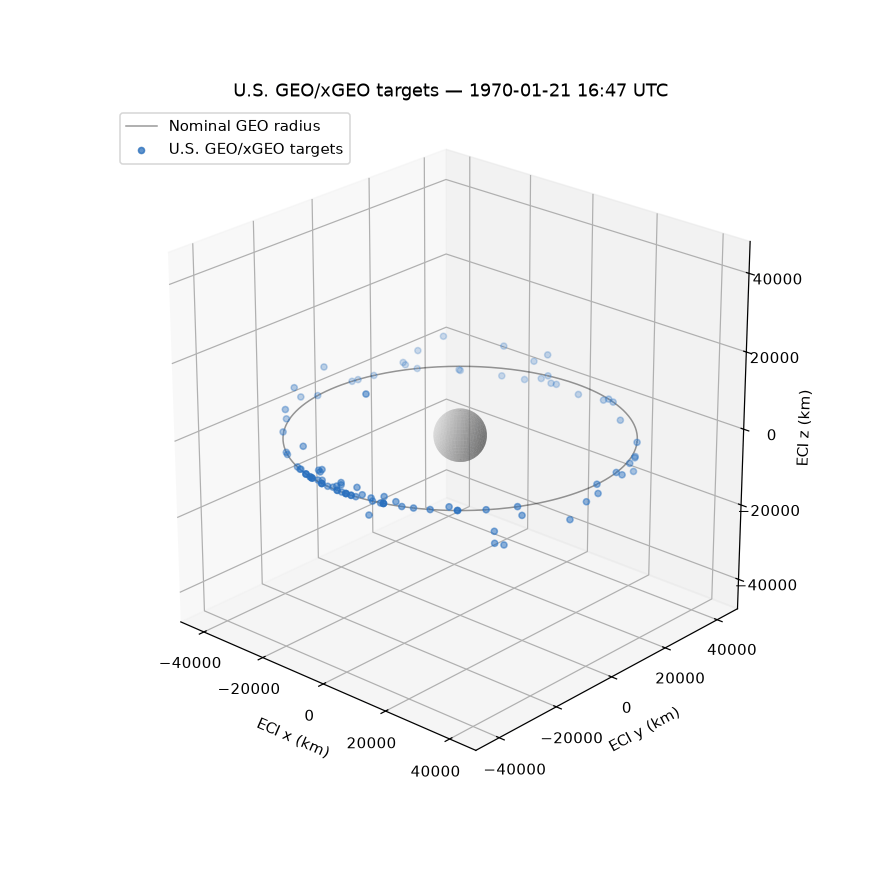

Saved GIF: outputs\xgeo_time_series_f0\geo_target_motion_eci.gif


In [8]:
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from IPython.display import Image, display

EARTH_RADIUS_KM = 6_378.0
GEO_RADIUS_KM = 42_164.0


def gmst_rad(timestamp):
    julian_date = timestamp.timestamp() / 86_400.0 + 2_440_587.5
    centuries = (julian_date - 2_451_545.0) / 36_525.0

    gmst_deg = (
        280.46061837
        + 360.98564736629 * (julian_date - 2_451_545.0)
        + 0.000387933 * centuries**2
        - centuries**3 / 38_710_000.0
    )

    return np.deg2rad(gmst_deg % 360.0)


def ecef_to_eci(ecef_xyz_km, epoch):
    """Convert saved Earth-fixed positions to inertial positions."""
    theta = gmst_rad(epoch)

    rotation = np.array(
        [
            [np.cos(theta), -np.sin(theta), 0.0],
            [np.sin(theta),  np.cos(theta), 0.0],
            [0.0,            0.0,           1.0],
        ]
    )

    return np.asarray(ecef_xyz_km) @ rotation.T


# Convert all 48 saved Earth-fixed snapshots to ECI for visualization.
target_eci_km = np.empty_like(target_ecef_km)

for frame, epoch in enumerate(time_grid):
    target_eci_km[frame] = ecef_to_eci(target_ecef_km[frame], epoch)

# Earth surface.
u, v = np.mgrid[0 : 2 * np.pi : 45j, 0 : np.pi : 24j]
earth_x = EARTH_RADIUS_KM * np.cos(u) * np.sin(v)
earth_y = EARTH_RADIUS_KM * np.sin(u) * np.sin(v)
earth_z = EARTH_RADIUS_KM * np.cos(v)

# Nominal GEO ring.
phi = np.linspace(0.0, 2.0 * np.pi, 300)
geo_ring_x = GEO_RADIUS_KM * np.cos(phi)
geo_ring_y = GEO_RADIUS_KM * np.sin(phi)
geo_ring_z = np.zeros_like(phi)

axis_limit_km = 48_000.0

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection="3d")

ax.plot_surface(
    earth_x,
    earth_y,
    earth_z,
    color="lightgray",
    alpha=0.50,
    linewidth=0,
)

ax.plot(
    geo_ring_x,
    geo_ring_y,
    geo_ring_z,
    color="black",
    alpha=0.40,
    linewidth=1.0,
    label="Nominal GEO radius",
)

satellite_points = ax.scatter(
    target_eci_km[0, :, 0],
    target_eci_km[0, :, 1],
    target_eci_km[0, :, 2],
    s=16,
    color="#276FBF",
    alpha=0.75,
    label="U.S. GEO/xGEO targets",
)

ax.set_xlim(-axis_limit_km, axis_limit_km)
ax.set_ylim(-axis_limit_km, axis_limit_km)
ax.set_zlim(-axis_limit_km, axis_limit_km)
ax.set_box_aspect([1, 1, 1])

ax.set_xlabel("ECI x (km)")
ax.set_ylabel("ECI y (km)")
ax.set_zlabel("ECI z (km)")
ax.view_init(elev=24, azim=-48)
ax.legend(loc="upper left")

title = ax.set_title("")


def update(frame):
    xyz = target_eci_km[frame]

    satellite_points._offsets3d = (
        xyz[:, 0],
        xyz[:, 1],
        xyz[:, 2],
    )

    title.set_text(
        "U.S. GEO/xGEO targets — "
        + time_grid[frame].strftime("%Y-%m-%d %H:%M UTC")
    )

    return satellite_points, title


animation = FuncAnimation(
    fig,
    update,
    frames=len(time_grid),
    interval=180,
    blit=False,
    repeat=True,
)

GIF_PATH = NPZ_PATH.with_name("geo_target_motion_eci.gif")

animation.save(
    GIF_PATH,
    writer=PillowWriter(fps=7),
    dpi=110,
)

plt.close(fig)

display(Image(filename=str(GIF_PATH)))
print(f"Saved GIF: {GIF_PATH}")